In [4]:
import pandas as pd

df = pd.read_csv("Milestone2_ModelReady.csv")

df["date"] = pd.to_datetime(df[["year","month","day"]])

df = df.sort_values("date")

print("Dataset Shape:", df.shape)
print("Date Range:", df["date"].min(), "to", df["date"].max())

print(df.head())

Dataset Shape: (1048, 19)
Date Range: 2023-02-08 00:00:00 to 2024-12-12 00:00:00
     demand_units  capacity_allocated  cost_usd  availability_pct  \
653         445.0                 439    837.93             99.88   
915         131.0                 357    431.17             99.19   
654         123.0                 570    345.53             99.79   
0           198.0                 461    396.14             99.47   
262         398.0                 624    653.52             99.62   

     customer_growth_rate  year  month  day  day_of_week  is_weekend  lag_1  \
653                 0.983  2023      2    8            2           0  205.0   
915                 1.030  2023      2    9            3           0   86.0   
654                 1.035  2023      2   10            4           0  445.0   
0                   1.069  2023      2   10            4           0  102.0   
262                 1.085  2023      2   11            5           1  160.0   

     lag_7  rolling_mean_7  d

In [5]:
daily_df = df.groupby("date")["demand_units"].sum().reset_index()

print("New Dataset Shape:", daily_df.shape)
print(daily_df.head())
print(daily_df.tail())

New Dataset Shape: (269, 2)
        date  demand_units
0 2023-02-08         445.0
1 2023-02-09         131.0
2 2023-02-10         321.0
3 2023-02-11         506.0
4 2023-02-12         267.0
          date  demand_units
264 2024-12-08         749.0
265 2024-12-09        1000.0
266 2024-12-10         930.0
267 2024-12-11        1340.0
268 2024-12-12        1226.0


In [6]:
train_size = int(len(daily_df) * 0.8)

train = daily_df.iloc[:train_size]
test = daily_df.iloc[train_size:]

print("Train size:", train.shape)
print("Test size:", test.shape)

print("Train date range:", train["date"].min(), "to", train["date"].max())
print("Test date range:", test["date"].min(), "to", test["date"].max())

Train size: (215, 2)
Test size: (54, 2)
Train date range: 2023-02-08 00:00:00 to 2024-08-06 00:00:00
Test date range: 2024-08-07 00:00:00 to 2024-12-12 00:00:00


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Naive forecast (last value)
naive_forecast = test["demand_units"].shift(1)

# remove first NaN
naive_forecast = naive_forecast.dropna()
actual = test["demand_units"][1:]

# evaluation
mae = mean_absolute_error(actual, naive_forecast)
rmse = np.sqrt(mean_squared_error(actual, naive_forecast))

print("Baseline MAE:", mae)
print("Baseline RMSE:", rmse)

Baseline MAE: 198.11320754716982
Baseline RMSE: 240.62573695059902


In [8]:
!pip install statsmodels

In [9]:
from statsmodels.tsa.arima.model import ARIMA

# train ARIMA model
model = ARIMA(train["demand_units"], order=(5,1,0))
model_fit = model.fit()

# forecast for test period
forecast = model_fit.forecast(steps=len(test))

# evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_arima = mean_absolute_error(test["demand_units"], forecast)
rmse_arima = np.sqrt(mean_squared_error(test["demand_units"], forecast))

print("ARIMA MAE:", mae_arima)
print("ARIMA RMSE:", rmse_arima)

ARIMA MAE: 195.37114974828907
ARIMA RMSE: 240.80443611807567


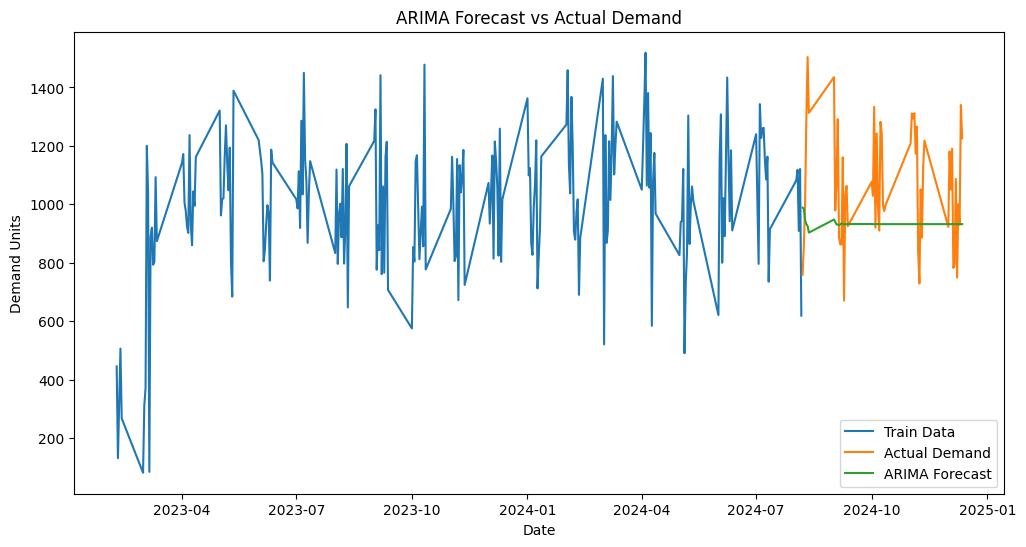

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(train["date"], train["demand_units"], label="Train Data")
plt.plot(test["date"], test["demand_units"], label="Actual Demand")
plt.plot(test["date"], forecast, label="ARIMA Forecast")

plt.xlabel("Date")
plt.ylabel("Demand Units")
plt.title("ARIMA Forecast vs Actual Demand")
plt.legend()

plt.show()

In [11]:
!pip install xgboost

In [12]:
from xgboost import XGBRegressor

# Load original dataset again (with features)
df = pd.read_csv("Milestone2_ModelReady.csv")

# Target
y = df["demand_units"]

# Features
X = df.drop(columns=["demand_units"])

# Train-test split
train_size = int(len(df) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# Train model
model = XGBRegressor(n_estimators=100, learning_rate=0.1)

model.fit(X_train, y_train)

# Predictions
pred = model.predict(X_test)

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, pred)
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred))

print("XGBoost MAE:", mae_xgb)
print("XGBoost RMSE:", rmse_xgb)

XGBoost MAE: 80.28851630801246
XGBoost RMSE: 98.8335907860569


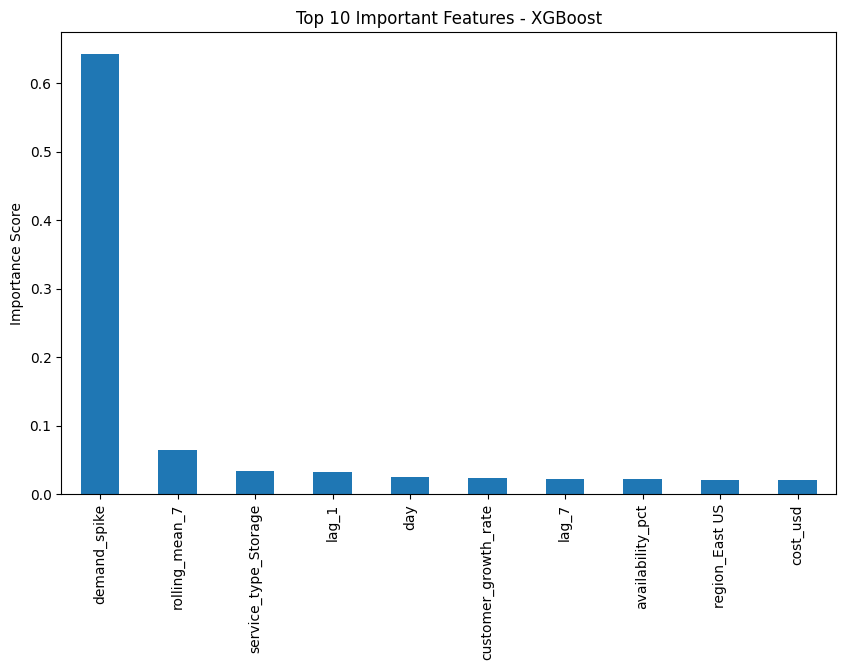

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

importance = model.feature_importances_

feature_names = X.columns

feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind="bar")

plt.title("Top 10 Important Features - XGBoost")
plt.ylabel("Importance Score")

plt.show()

Model Comparison

Baseline Model
MAE: 198.11
RMSE: 240.63

ARIMA Model
MAE: 195.37
RMSE: 240.80

XGBoost Model
MAE: 80.29
RMSE: 98.83

XGBoost achieved the lowest MAE and RMSE, making it the best model for forecasting Azure demand.

Final Model Selection

Among all models tested, XGBoost performed the best with the lowest prediction errors.
It effectively captured complex demand patterns using engineered features such as lag variables, rolling averages, customer growth rate, and regional demand indicators.
Therefore, XGBoost was selected as the final forecasting model for the Azure demand prediction system.